
<img align="right" width="125" src="https://www.ou.nl/documents/40554/3255217/Logo_OU.jpg"/>

<br>


<center> <font size ="6" color='red'> AI for Prescriptive Analysis </font></center>
<br> 
<center> <font size ="5" color='red'> Discrete Event Simulation in Python</font></center>
<br> 


--------------------------


In [2]:
from controller import *
from ipywidgets import widgets
mycontroller = Controller()
mytab = mycontroller.GetDashBoard(); milptab = mycontroller.GenerateMILPTab()
tab_set = widgets.Tab([mytab,milptab])
tab_set.set_title(0,'Main');tab_set.set_title(1,'MILP'); tab_set

Start day:  2026-09-04  weekday:  4  day:  Friday , TimeLimit:  None
Controller: Generating dashboard
Visual Manager: Generating dashboard


Item batches: 35
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  CentralBuffer_Location
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_60
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_61
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_62
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  Trailer_63
+++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Location:  BW_(BKW_01)_Location
Machine Setup 43 BW_(BKW_01)_Location 1962
Machine Loading 222 BW_(BKW_01)_Location 2038
Machine Processing 252 BW_(BKW_01)_Location 2087
Machine Unloading 271 BW_(BKW_01)_Location 2238
Machine Setup 44 BW_(BKW_01)_Location 2240
Machine Loading 289 BW_(BKW_01)_Location 2255
Machine Processing 300 BW_(BKW_01)_Location 2495
Machine Unloading 333 BW_(BKW_01)_Location 3362
Machine Setup 45 BW_(BKW_01)_Location 3364
Machine Loading 342 BW_(BKW_01)_Location 3366
Machine Processing 3

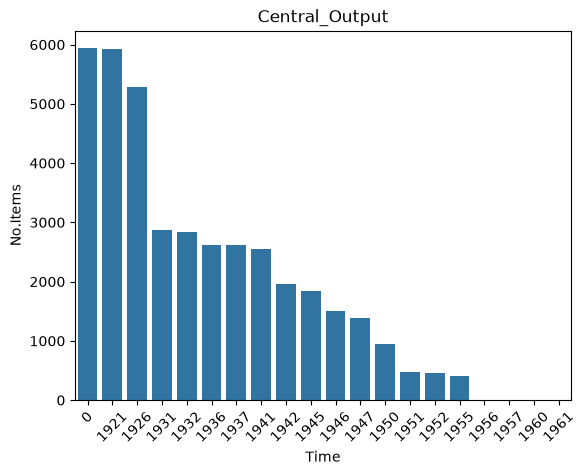

,BufferName,Time,No.Items
0,Central_Output,0,5941
1,Central_Output,1921,5924
2,Central_Output,1926,5286
3,Central_Output,1931,2865
4,Central_Output,1932,2841
5,Central_Output,1936,2617
6,Central_Output,1937,2616
7,Central_Output,1941,2552
8,Central_Output,1942,1952
9,Central_Output,1945,1848


______________________________


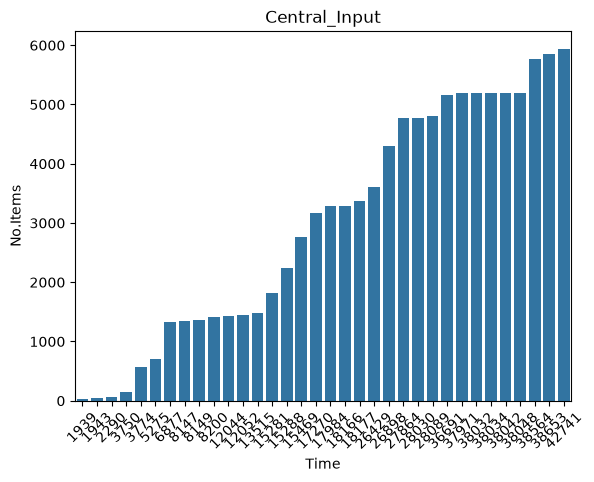

,BufferName,Time,No.Items
0,Central_Input,1939,24
1,Central_Input,1943,44
2,Central_Input,2290,61
3,Central_Input,3750,153
4,Central_Input,3774,573
5,Central_Input,5275,707
6,Central_Input,6877,1323
7,Central_Input,8147,1343
8,Central_Input,8149,1367
9,Central_Input,8200,1413


______________________________


In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

diagnose = True

print("Item batches: "+str(len(exec_df["Items"].unique())))

for batch in exec_df["Items"].unique():
    if pd.isnull(batch):
        continue
    sub_df = exec_df[exec_df["Items"] == batch]
    sub_df = sub_df.sort_values(['SimTime'])
    start = sub_df.iloc[0, sub_df.columns.get_loc('Location')]
    end = sub_df.iloc[len(sub_df)-1, sub_df.columns.get_loc('Location')]

    #if start != end:
    #    display(sub_df)
    
    #    print("______________________________")
    

#process_df = exec_df[exec_df["EventName"] == "Machine Processing"]

for myloc in exec_df["Location"].unique():
    print("+++++++++++++++++++++++++++++++++++++++++++++++++++++++++")
    print("Location: ",myloc)
    sub_df = exec_df[exec_df["Location"] == myloc]
    sub_df  = sub_df[(sub_df["EventName"] == "Machine Setup") | (sub_df["EventName"] =="Machine Loading") | (sub_df["EventName"] == "Machine Processing") | (sub_df["EventName"] == "Machine Unloading")]
    if diagnose and len(sub_df)  > 0:
        for i,r in sub_df.iterrows():
            print(r["EventName"],r["EventID"],r["Location"],r["SimTime"])
        
        #display(sub_df)

    


print("~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~")
exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "BufferData.csv"))

for buff in exec_df["BufferName"].unique():
    sub_df = exec_df[exec_df["BufferName"] == buff]
    agg_df = sub_df.groupby(['BufferName','Time'])['No.Items'].max().reset_index()
    agg_df = agg_df.rename(columns={agg_df.columns[-1]: "No.Items"})

    if buff in ["Central_Output","Central_Input"]:
        sns.barplot(agg_df, x="Time", y="No.Items", legend=False).set_title(buff)
        plt.xticks(rotation=45)
        plt.show()
        
        display(agg_df.head(100))
        print("______________________________")    

In [5]:
import pandas as pd

location_df = pd.read_csv(os.path.join("..", "data", "simulation", "LocationData.csv"))

for entity in location_df["EntityID"].unique():
    sub_df = location_df[location_df["EntityID"] == entity]
    display(sub_df)
    print("______________________________")
    

,EntityName,EntityID,Time,LocationName,LocationID
0,Operator 1,4,1921,CentralBuffer_Location,0
4,Operator 1,4,1922,CentralBuffer_Location,0
8,Operator 1,4,1923,BW_(BKW_01)_Location,13
12,Operator 1,4,1925,BW_(BKW_01)_Location,13
16,Operator 1,4,1926,CentralBuffer_Location,0
...,...,...,...,...,...
823,Operator 1,4,42639,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
824,Operator 1,4,42640,PACK_(VERP_P)_Location,14
825,Operator 1,4,42642,PACK_(VERP_P)_Location,14
826,Operator 1,4,42644,PACK_(VERP_P)_Location,14


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
1,Operator 2,5,1921,CentralBuffer_Location,0
5,Operator 2,5,1922,CentralBuffer_Location,0
9,Operator 2,5,1923,BW_(BKW_01)_Location,13
13,Operator 2,5,1925,BW_(BKW_01)_Location,13
17,Operator 2,5,1926,CentralBuffer_Location,0
...,...,...,...,...,...
789,Operator 2,5,38044,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
790,Operator 2,5,38045,CentralBuffer_Location,0
791,Operator 2,5,38046,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
792,Operator 2,5,38047,OUT - Outsourced activity_(OUT - Outsourced)_L...,15


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
2,Manual worker 1,7,1921,CentralBuffer_Location,0
6,Manual worker 1,7,1922,CentralBuffer_Location,0
10,Manual worker 1,7,1923,BW_(BKW_01)_Location,13
14,Manual worker 1,7,1925,BW_(BKW_01)_Location,13
18,Manual worker 1,7,1926,CentralBuffer_Location,0
...,...,...,...,...,...
641,Manual worker 1,7,18152,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
643,Manual worker 1,7,18153,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
645,Manual worker 1,7,18155,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
647,Manual worker 1,7,18157,OUT - Outsourced activity_(OUT - Outsourced)_L...,15


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
3,Manual worker 2,8,1921,CentralBuffer_Location,0
7,Manual worker 2,8,1922,CentralBuffer_Location,0
11,Manual worker 2,8,1923,BW_(BKW_01)_Location,13
15,Manual worker 2,8,1925,BW_(BKW_01)_Location,13
19,Manual worker 2,8,1926,CentralBuffer_Location,0
...,...,...,...,...,...
634,Manual worker 2,8,18149,CentralBuffer_Location,0
637,Manual worker 2,8,18150,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
639,Manual worker 2,8,18151,OUT - Outsourced activity_(OUT - Outsourced)_L...,15
642,Manual worker 2,8,18152,OUT - Outsourced activity_(OUT - Outsourced)_L...,15


______________________________


,EntityName,EntityID,Time,LocationName,LocationID
235,Operator 3,6,2401,CentralBuffer_Location,0
236,Operator 3,6,2880,CentralBuffer_Location,0
297,Operator 3,6,3959,CentralBuffer_Location,0
298,Operator 3,6,3960,BW_(BKW_01)_Location,13
299,Operator 3,6,3962,BW_(BKW_01)_Location,13
...,...,...,...,...,...
830,Operator 3,6,42737,PACK_(VERP_P)_Location,14
831,Operator 3,6,42738,CentralBuffer_Location,0
832,Operator 3,6,42739,PACK_(VERP_P)_Location,14
833,Operator 3,6,42740,PACK_(VERP_P)_Location,14


______________________________


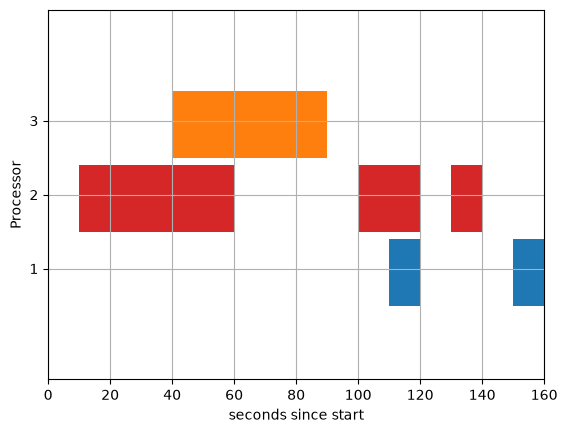

In [6]:
# Importing the matplotlib.pyplot
import matplotlib.pyplot as plt

# Declaring a figure "gnt"
fig, gnt = plt.subplots()

# Setting Y-axis limits
gnt.set_ylim(0, 50)

# Setting X-axis limits
gnt.set_xlim(0, 160)

# Setting labels for x-axis and y-axis
gnt.set_xlabel('seconds since start')
gnt.set_ylabel('Processor')

# Setting ticks on y-axis
gnt.set_yticks([15, 25, 35])
# Labelling tickes of y-axis
gnt.set_yticklabels(['1', '2', '3'])

# Setting graph attribute
gnt.grid(True)

# Declaring a bar in schedule
gnt.broken_barh([(40, 50)], (30, 9), facecolors =('tab:orange'))

# Declaring multiple bars in at same level and same width
gnt.broken_barh([(110, 10), (150, 10)], (10, 9),
                         facecolors ='tab:blue')

gnt.broken_barh([(10, 50), (100, 20), (130, 10)], (20, 9),
                                  facecolors =('tab:red'))


In [7]:
import pandas as pd

exec_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

demands_df = exec_df.groupby(['Items','ID','Product','Work Orders/Operation','EventName','EventID','Resource','Date'])['SimTime'].agg(lambda x:list(x)).reset_index()

for demand in demands_df['ID'].unique():
    demand_df = demands_df[demands_df["ID"] == demand]
    demand_df['Date']  = pd.to_datetime(demand_df['Date'], format="%Y-%m-%d %H:%M:%S")
    display(demand_df)


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
0,1296~1429,__export__.mrp_production_6210_afc3a4ad,[1508130 B] [Q] excenter housing z,-,Trailer Unloading,483,Operator 1,2026-09-02 15:55:00,[5275]
1,1296~1429,__export__.mrp_production_6210_afc3a4ad,[1508130 B] [Q] excenter housing z,BW - Benchwork (BKW_01),Machine Processing,422,BW_(BKW_01),2026-09-02 13:20:00,[5120]
2,1296~1429,__export__.mrp_production_6210_afc3a4ad,[1508130 B] [Q] excenter housing z,Packaging (VERP_P),Machine Processing,459,PACK_(VERP_P),2026-09-02 15:46:00,[5266]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
3,1430~1953,__export__.mrp_production_7098_92dba811,[4022-666-65702(R1)] LSPH coverplate stud block,-,Trailer Unloading,701,Operator 3,2026-09-09 17:49:00,[15469]
4,1430~1953,__export__.mrp_production_7098_92dba811,[4022-666-65702(R1)] LSPH coverplate stud block,Anodising,Machine Processing,539,OUT - Outsourced activity_(OUT - Outsourced),2026-09-09 15:43:00,[15343]
5,1430~1953,__export__.mrp_production_7098_92dba811,[4022-666-65702(R1)] LSPH coverplate stud block,BW - Benchwork (BKW_01),Machine Processing,527,BW_(BKW_01),2026-09-03 09:54:00,[6354]
6,1430~1953,__export__.mrp_production_7098_92dba811,[4022-666-65702(R1)] LSPH coverplate stud block,Milling (FR3_01),Machine Processing,438,M3-01_(FR3_01),2026-09-02 14:28:00,[5188]
7,1430~1953,__export__.mrp_production_7098_92dba811,[4022-666-65702(R1)] LSPH coverplate stud block,Packaging (VERP_P),Machine Processing,691,PACK_(VERP_P),2026-09-09 17:40:00,[15460]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
8,144~167,__export__.mrp_production_5680_ed5f1e28,[4022.622.61481] RH RED GRIPPER TUNGSTEN MASS,-,Trailer Unloading,978,Operator 1,2026-09-25 08:51:00,[37971]
9,144~167,__export__.mrp_production_5680_ed5f1e28,[4022.622.61481] RH RED GRIPPER TUNGSTEN MASS,External Milling Tungsten,Machine Processing,259,OUT - Outsourced activity_(OUT - Outsourced),2026-09-25 08:43:00,[37963]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
10,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,-,Trailer Unloading,400,Operator 1,2026-09-01 14:30:00,[3750]
11,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,BW - Benchwork (BKW_01),Machine Processing,344,BW_(BKW_01),2026-09-01 12:40:00,[3640]
12,168~259,__export__.mrp_production_6199_a3feca82,[4598-008-08901B POS 1] CEILING INLET*,Packaging (VERP_P),Machine Processing,381,PACK_(VERP_P),2026-09-01 14:22:00,[3742]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
13,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,-,Trailer Unloading,598,Operator 3,2026-09-04 16:40:00,[8200]
14,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,Packaging (VERP_P),Machine Processing,584,PACK_(VERP_P),2026-09-04 16:31:00,[8191]
15,18~63,__export__.mrp_production_6192_3443eb6e,[M0216-01-363-B] nul-graden arretsegment,Passivating,Machine Processing,254,OUT - Outsourced activity_(OUT - Outsourced),2026-09-04 15:31:00,[8131]


...

,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
91,5939~5939,__export__.mrp_production_5034_4d53b4c4,[4022.684.29043] RS C+H DYN ATTACH PLT IL SIDE...,-,Trailer Unloading,996,Operator 1,2026-09-25 09:52:00,[38032]
92,5939~5939,__export__.mrp_production_5034_4d53b4c4,[4022.684.29043] RS C+H DYN ATTACH PLT IL SIDE...,Cleaning,Machine Processing,835,OUT - Outsourced activity_(OUT - Outsourced),2026-09-25 09:43:00,[38023]
93,5939~5939,__export__.mrp_production_5034_4d53b4c4,[4022.684.29043] RS C+H DYN ATTACH PLT IL SIDE...,Nickel Plating,Machine Processing,281,OUT - Outsourced activity_(OUT - Outsourced),2026-09-11 14:22:00,[18142]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
94,5940~5940,__export__.mrp_production_5035_e3dce293,[4022.684.28962] RS C+H DYN ATTACH PLT RH SIDE...,-,Trailer Unloading,1009,Operator 1,2026-09-25 10:02:00,[38042]
95,5940~5940,__export__.mrp_production_5035_e3dce293,[4022.684.28962] RS C+H DYN ATTACH PLT RH SIDE...,Cleaning,Machine Processing,839,OUT - Outsourced activity_(OUT - Outsourced),2026-09-25 09:53:00,[38033]
96,5940~5940,__export__.mrp_production_5035_e3dce293,[4022.684.28962] RS C+H DYN ATTACH PLT RH SIDE...,Nickel Plating,Machine Processing,279,OUT - Outsourced activity_(OUT - Outsourced),2026-09-11 14:26:00,[18146]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
97,5941~5941,__export__.mrp_production_5036_bec2ca68,[4022.684.28842] RS C+H SLAB STAT PLT RH SIDE ...,-,Trailer Unloading,1016,Operator 2,2026-09-25 10:08:00,[38048]
98,5941~5941,__export__.mrp_production_5036_bec2ca68,[4022.684.28842] RS C+H SLAB STAT PLT RH SIDE ...,Cleaning,Machine Processing,838,OUT - Outsourced activity_(OUT - Outsourced),2026-09-25 09:59:00,[38039]
99,5941~5941,__export__.mrp_production_5036_bec2ca68,[4022.684.28842] RS C+H SLAB STAT PLT RH SIDE ...,Nickel Plating,Machine Processing,280,OUT - Outsourced activity_(OUT - Outsourced),2026-09-11 14:22:00,[18142]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
100,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,-,Trailer Unloading,1046,Operator 3,2026-09-25 20:13:00,[38653]
101,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,BW - Benchwork (BKW_01),Machine Processing,300,BW_(BKW_01),2026-08-31 17:35:00,[2495]
102,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,Packaging (VERP_P),Machine Processing,1038,PACK_(VERP_P),2026-09-25 20:05:00,[38645]
103,64~143,__export__.mrp_production_6020_2cead996,[4598-008-08901B POS 1] CEILING INLET*,Painting,Machine Processing,354,OUT - Outsourced activity_(OUT - Outsourced),2026-09-25 14:43:00,[38323]


,Items,ID,Product,Work Orders/Operation,EventName,EventID,Resource,Date,SimTime
104,876~1295,__export__.mrp_production_6209_9f61b525,[00429-00-662-B] Arret lever,-,Trailer Unloading,408,Manual worker 1,2026-09-01 14:54:00,[3774]
105,876~1295,__export__.mrp_production_6209_9f61b525,[00429-00-662-B] Arret lever,Milling (FR3-01),Machine Processing,377,BW_(BKW_01),2026-09-01 13:25:00,[3685]
106,876~1295,__export__.mrp_production_6209_9f61b525,[00429-00-662-B] Arret lever,Packaging (VERP_P),Machine Processing,398,PACK_(VERP_P),2026-09-01 14:46:00,[3766]


In [9]:
import pandas as pd 

milp_schedule_df = pd.read_csv(os.path.join("..", "data", "schedules", "TBRM_Plan_2026-08-19_R3_2026-08-28.csv"))

sim_schedule_df = pd.read_csv(os.path.join("..", "data", "simulation", "EventExecutionData.csv"))

sim_schedule_df = sim_schedule_df[["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Work Orders/Expected Duration","Work Orders/Start(SIM)","Work Orders/End(SIM)","Work Orders/Status(SIM)","Tardy(SIM)","Lateness (days)(SIM)"]]

schedule_df = pd.merge(milp_schedule_df, sim_schedule_df,  how="left", on=["ID","Product","Product/ID","Quantity To Produce","Deadline","Reference","Work Orders/Work Center","Work Orders/Work Center/ID","Work Orders/Operation","Work Orders/Expected Duration"])

schedule_df.to_csv(os.path.join("..", "data", "schedules", "Combined_Schedule.csv"),index = False)